### Load Library

In [1]:
import pandas as pd
env_amr_df = pd.read_csv("data/env_amr_df.tsv", sep='\t')

### Kruskal-Wallis H-test

In [2]:
import scipy.stats as stats

# 1. Calculate total AMR load (CPM) for EACH sample
sample_amr_load = env_amr_df.groupby(['Sample_ID', 'Location'])['CPM'].sum().reset_index()

# 2. Extract the CPM values as lists grouped by Location
locations = sample_amr_load['Location'].unique()
cpm_by_location = []

for loc in locations:
    values = sample_amr_load[sample_amr_load['Location'] == loc]['CPM'].values
    if len(values) > 0:
        cpm_by_location.append(values)

# 3. Run the Kruskal-Wallis H-test
stat, p_value = stats.kruskal(*cpm_by_location)

print("--- Statistical Test Results (Kruskal-Wallis) ---")
print(f"H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: The difference in AMR burden between cleanroom locations is STATISTICALLY SIGNIFICANT.")
else:
    print("\nConclusion: The difference is not statistically significant (p >= 0.05).")

--- Statistical Test Results (Kruskal-Wallis) ---
H-statistic: 8.5686
P-value: 2.8513e-01

Conclusion: The difference is not statistically significant (p >= 0.05).


### Alpha Diversity

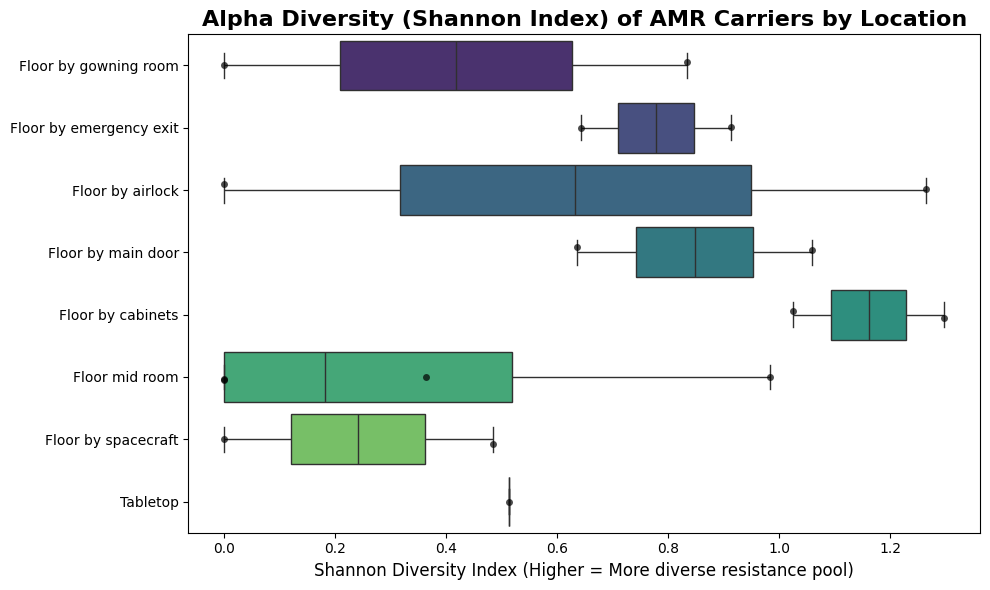

In [3]:
import numpy as np
from scipy.stats import entropy
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a Sample-by-Genus matrix (rows = samples, columns = genus, values = CPM)
genus_sample_matrix = env_amr_df.pivot_table(
    index='Sample_ID', 
    columns='genus', 
    values='CPM', 
    aggfunc='sum', 
    fill_value=0
)

# 2. Function to calculate Shannon Index
def shannon_index(row):
    # Ignore zero values
    proportions = row[row > 0] / row.sum()
    return entropy(proportions, base=np.e)

# 3. Apply to our matrix
alpha_diversity = genus_sample_matrix.apply(shannon_index, axis=1).reset_index()
alpha_diversity.columns = ['Sample_ID', 'Shannon_Index']

# Merge the Location data back in
alpha_diversity = alpha_diversity.merge(sample_amr_load[['Sample_ID', 'Location']], on='Sample_ID')

# 4. Plot Alpha Diversity
plt.figure(figsize=(10, 6))
sns.boxplot(data=alpha_diversity, x='Shannon_Index', y='Location', hue='Location', palette='viridis', fliersize=0, legend=False)
sns.stripplot(data=alpha_diversity, x='Shannon_Index', y='Location', color='black', alpha=0.7, jitter=True)

plt.title('Alpha Diversity (Shannon Index) of AMR Carriers by Location', fontsize=16, fontweight='bold')
plt.xlabel('Shannon Diversity Index (Higher = More diverse resistance pool)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.savefig("data/result/alpha_diversity.png", dpi=300)
plt.show()

### Beta Diversity

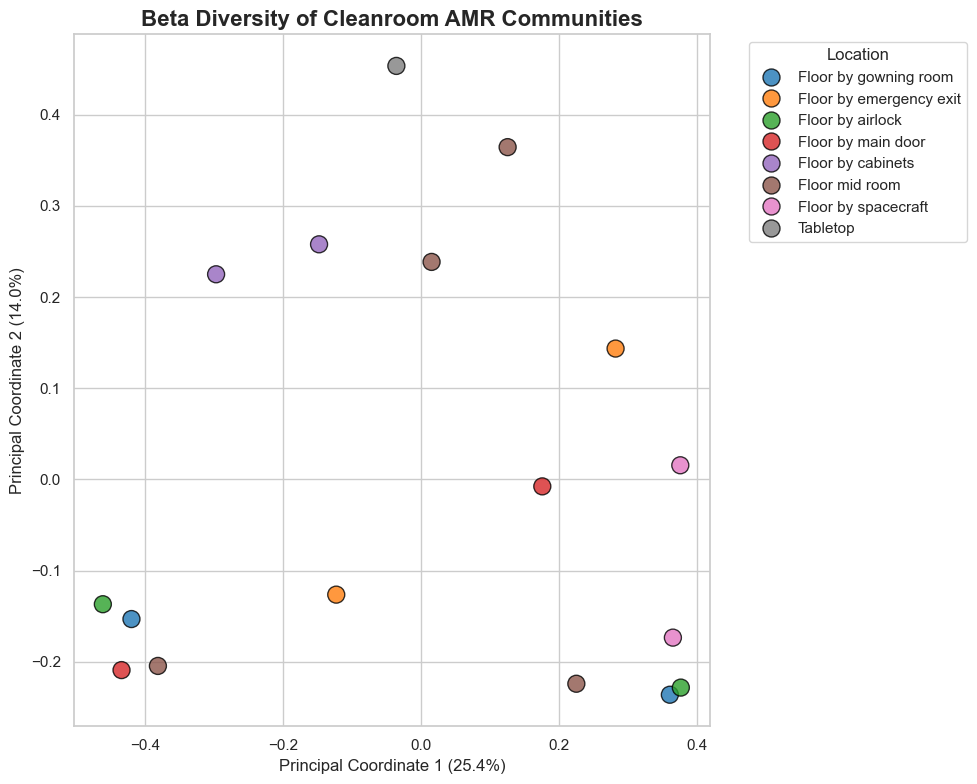

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import pdist, squareform
from skbio.stats.ordination import pcoa
from skbio import DistanceMatrix

# Set the visual style for the plot
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 1. Calculate the Bray-Curtis distance matrix
bc_distance = pdist(genus_sample_matrix, metric='braycurtis')
bc_distance_matrix = squareform(bc_distance)

# 2. Apply the Square Root transformation to fix negative eigenvalues
bc_distance_matrix_sqrt = np.sqrt(bc_distance_matrix)

# 3. Create the scikit-bio DistanceMatrix object
dm = DistanceMatrix(bc_distance_matrix_sqrt, ids=genus_sample_matrix.index)

# 4. Run true analytical PCoA (Classical MDS)
# Catch harmless warnings and strictly specify 2 dimensions to save compute time
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    pcoa_results = pcoa(dm, number_of_dimensions=2)

# 5. Extract coordinates and build the DataFrame for plotting
pcoa_df = pcoa_results.samples[['PC1', 'PC2']].copy()
pcoa_df['Sample_ID'] = pcoa_df.index

# Merge the coordinates with your sample metadata (Location)
pcoa_df = pcoa_df.merge(sample_amr_load[['Sample_ID', 'Location']], on='Sample_ID')

# Extract the variance explained for the axis labels
pc1_var = pcoa_results.proportion_explained['PC1'] * 100
pc2_var = pcoa_results.proportion_explained['PC2'] * 100

# 6. Plot the PCoA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pcoa_df, 
    x='PC1', 
    y='PC2', 
    hue='Location', 
    s=150, 
    palette='tab10', 
    edgecolor='black', 
    alpha=0.8
)

# Format the plot titles and labels
plt.title('Beta Diversity of Cleanroom AMR Communities', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Coordinate 1 ({pc1_var:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Coordinate 2 ({pc2_var:.1f}%)', fontsize=12)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Location")
plt.tight_layout()

# Save the figure in high resolution
plt.savefig("data/result/beta_diversity_true_pcoa.png", dpi=300)
plt.show()

### PERMANOVA Results

In [6]:
# Install scikit-bio if you don't have it yet
# !pip install scikit-bio
import numpy as np
from skbio.stats.distance import permanova
from skbio import DistanceMatrix

# 1. Create a scikit-bio DistanceMatrix object
# We are reusing the 'bc_distance_matrix' and 'genus_sample_matrix' you already built in the PCoA step
dm = DistanceMatrix(bc_distance_matrix, ids=genus_sample_matrix.index)

# 2. Format the metadata
# PERMANOVA requires a dataframe where the index matches the distance matrix IDs exactly
metadata = sample_amr_load.drop_duplicates(subset=['Sample_ID']).set_index('Sample_ID')

# 3. Run the PERMANOVA test
# We use 999 permutations, which is the gold standard for ecological statistics
np.random.seed(42)
permanova_results = permanova(dm, metadata, column='Location', permutations=999)

print("--- PERMANOVA Results (Beta Diversity Significance) ---")
print(permanova_results)

--- PERMANOVA Results (Beta Diversity Significance) ---
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      17
number of groups                  8
test statistic             1.123039
p-value                       0.321
number of permutations          999
Name: PERMANOVA results, dtype: object
